In [1]:
# Imports and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/processed/daily_sales_store1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nMissing values:', df.isnull().sum().sum())

Shape: (1684, 2)

First 5 rows:
            total_sales  dcoilwtico
date                               
2013-01-01     0.000000       93.14
2013-01-02  7417.148000       93.14
2013-01-03  5873.244001       92.97
2013-01-04  5919.879001       93.12
2013-01-05  6318.785010       93.12

Missing values: 0


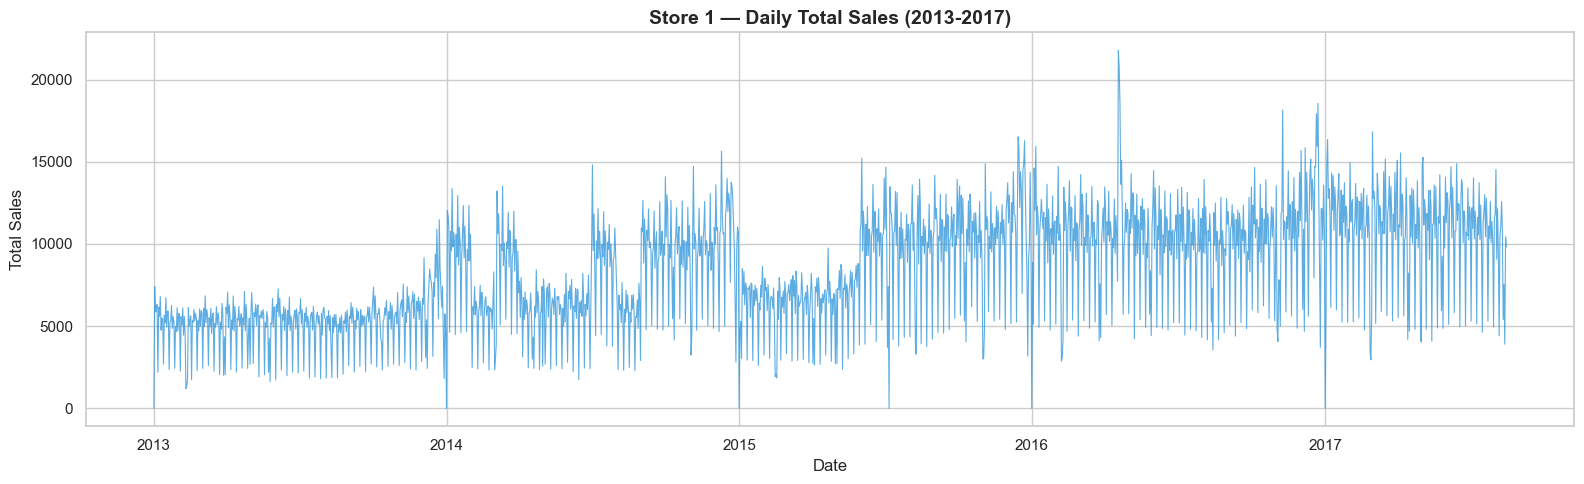

In [ ]:
# Raw sales over time

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['total_sales'],
        color='#3498db', linewidth=0.8, alpha=0.8)

ax.set_title('Store 1 — Daily Total Sales (2013-2017)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('../reports/figures/01_raw_sales.png',
            dpi=150, bbox_inches='tight')
plt.show()

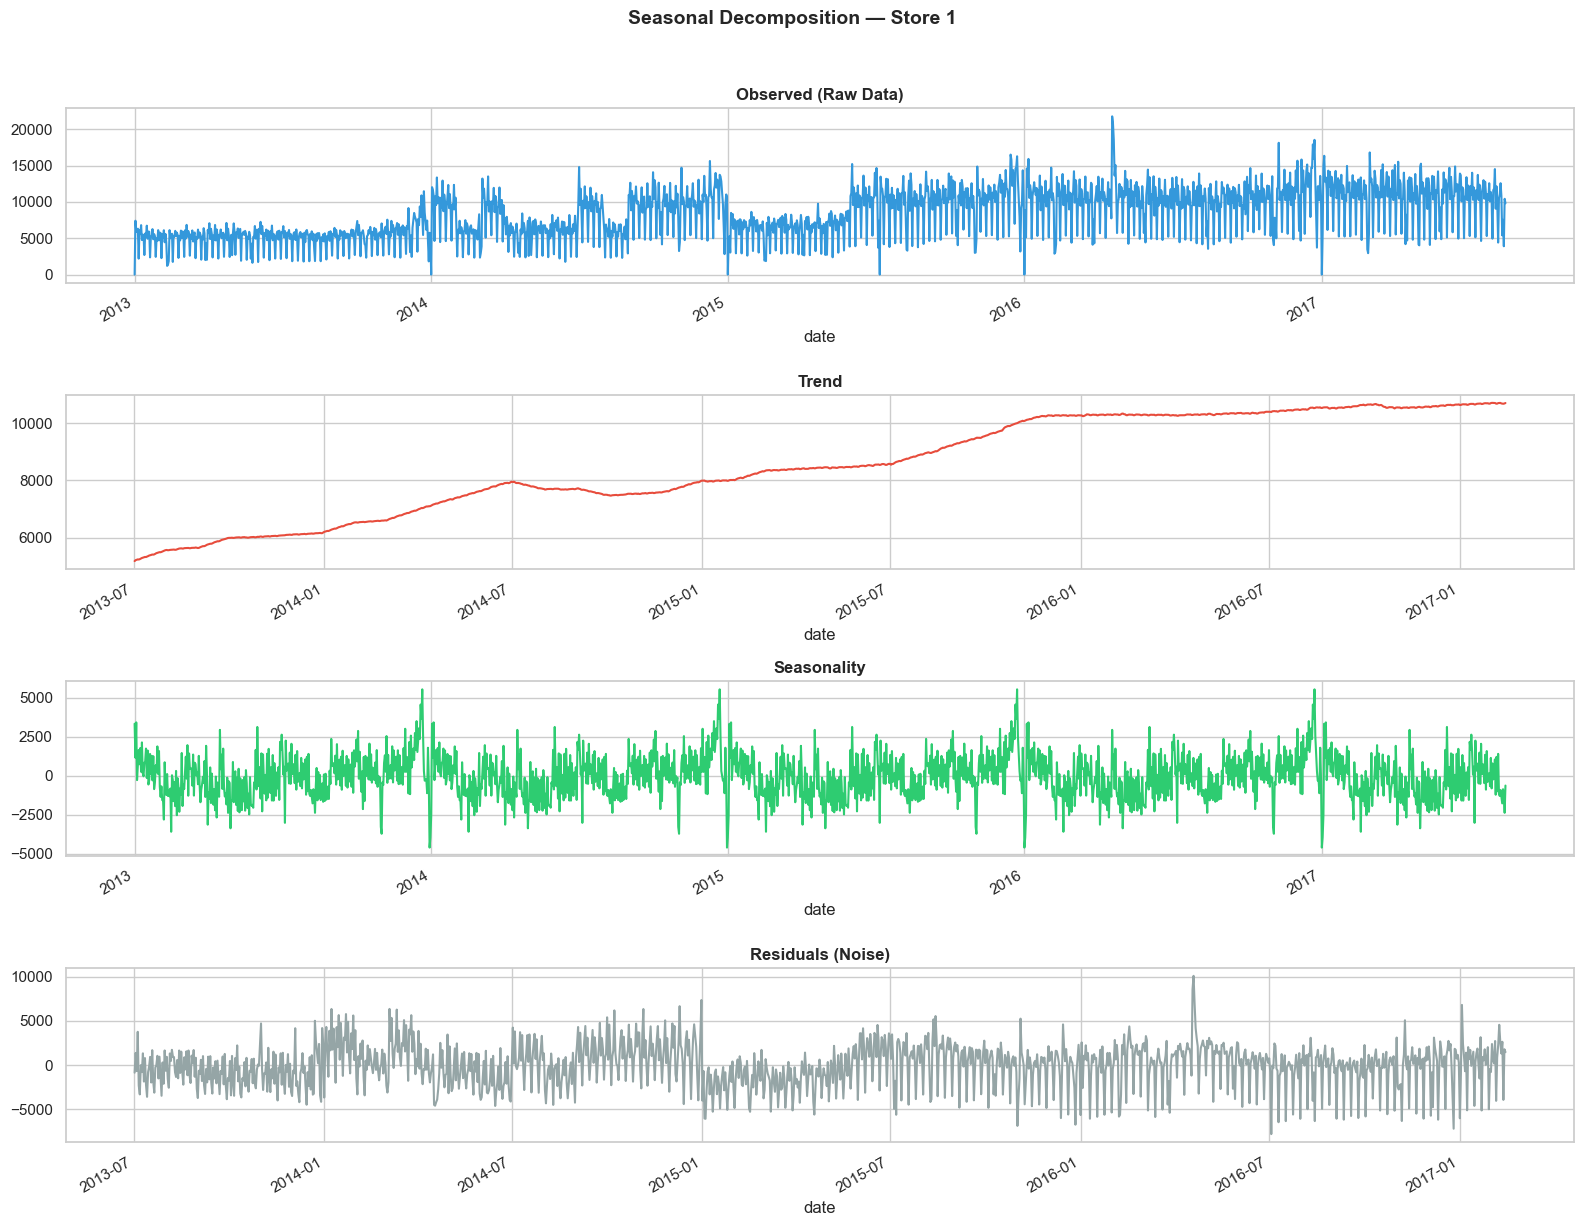

In [3]:
# Seasonality Decomposition

decomposition = seasonal_decompose(
    df['total_sales'],
    model='additive',
    period=365
)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

decomposition.observed.plot(ax=axes[0], color='#3498db')
axes[0].set_title('Observed (Raw Data)', fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='#e74c3c')
axes[1].set_title('Trend', fontweight='bold')

decomposition.seasonal.plot(ax=axes[2], color='#2ecc71')
axes[2].set_title('Seasonality', fontweight='bold')

decomposition.resid.plot(ax=axes[3], color='#95a5a6')
axes[3].set_title('Residuals (Noise)', fontweight='bold')

plt.suptitle('Seasonal Decomposition — Store 1',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/02_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

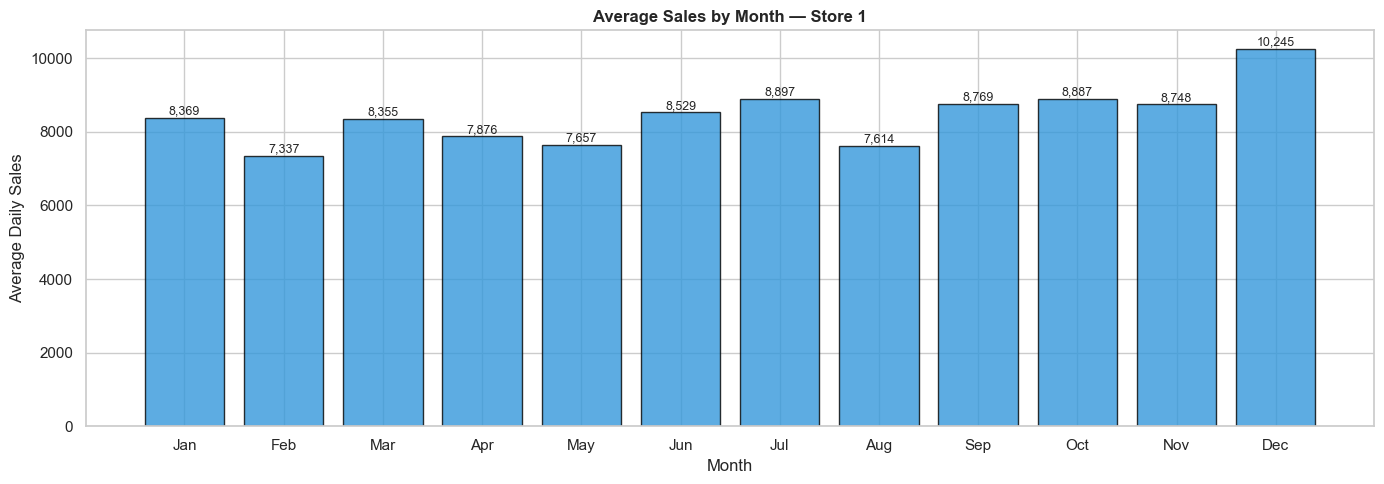

In [ ]:
# Monthly Sales Pattern

df['month'] = df.index.month
df['year']  = df.index.year

monthly_avg = df.groupby('month')['total_sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(month_names, monthly_avg.values,
              color='#3498db', edgecolor='black', alpha=0.8)

ax.set_title('Average Sales by Month — Store 1',
             fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Daily Sales')

for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val:,.0f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/03_monthly_pattern.png',
            dpi=150, bbox_inches='tight')
plt.show()

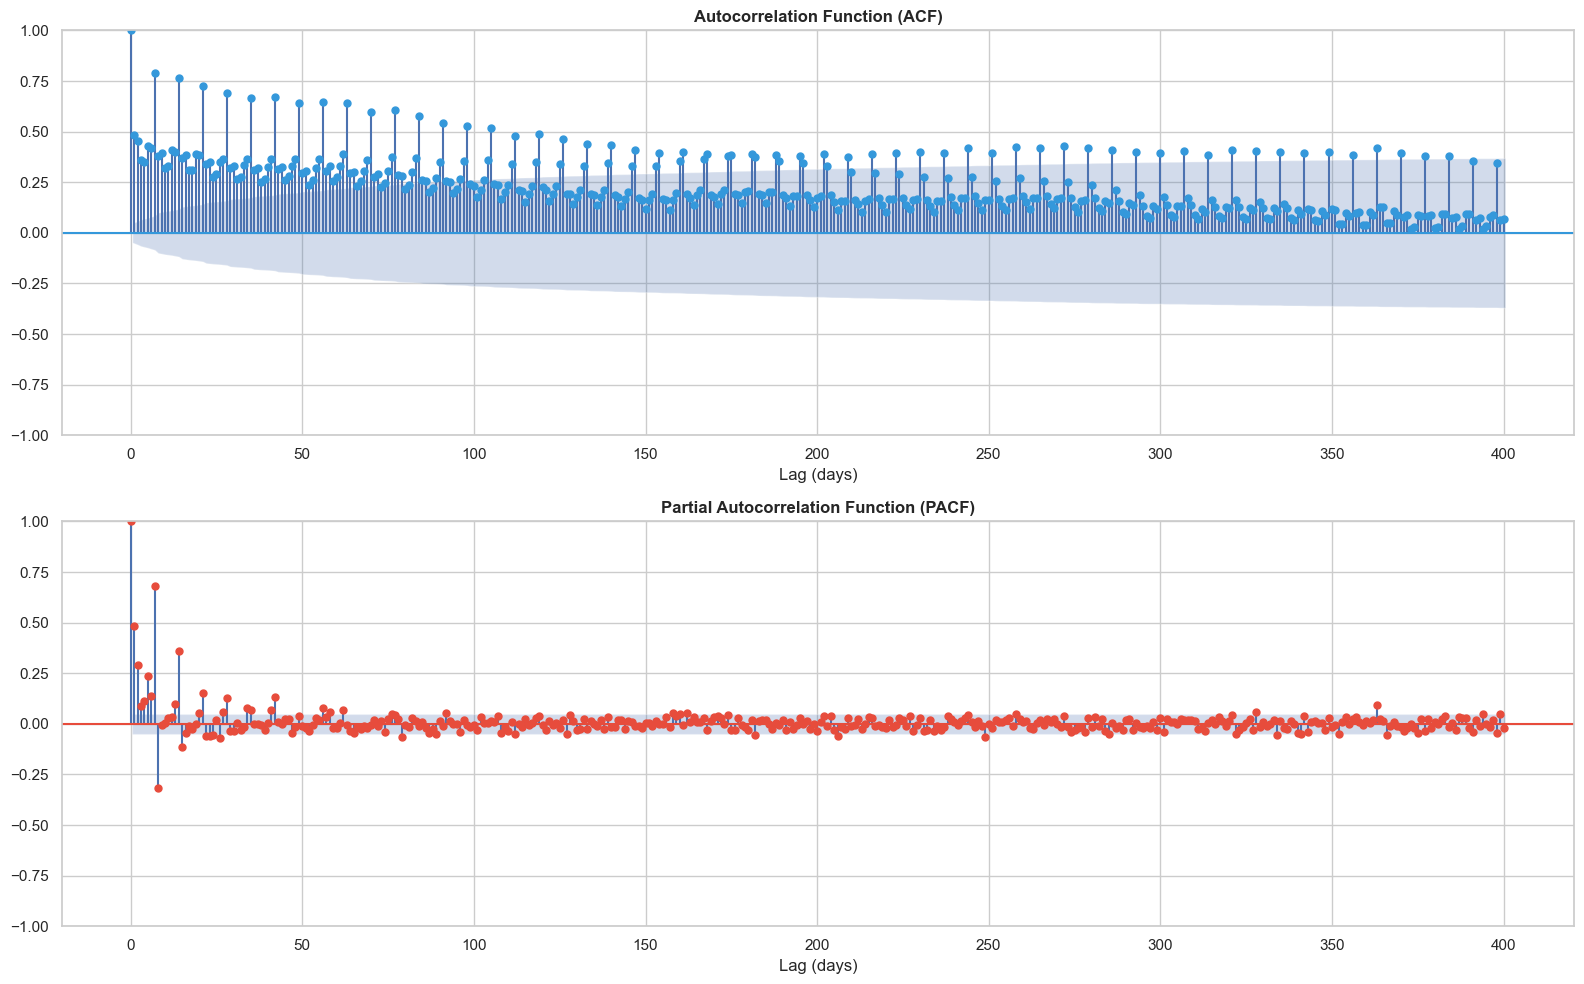

In [9]:
# Autocorrelation Plot

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_acf(df['total_sales'],
         lags=400,
         ax=axes[0],
         color='#3498db')
axes[0].set_title('Autocorrelation Function (ACF)',
                  fontweight='bold')
axes[0].set_xlabel('Lag (days)')

plot_pacf(df['total_sales'],
          lags=400,
          ax=axes[1],
          color='#e74c3c',
          method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)',
                  fontweight='bold')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.savefig('../reports/figures/04_autocorrelation.png',
            dpi=150, bbox_inches='tight')
plt.show()

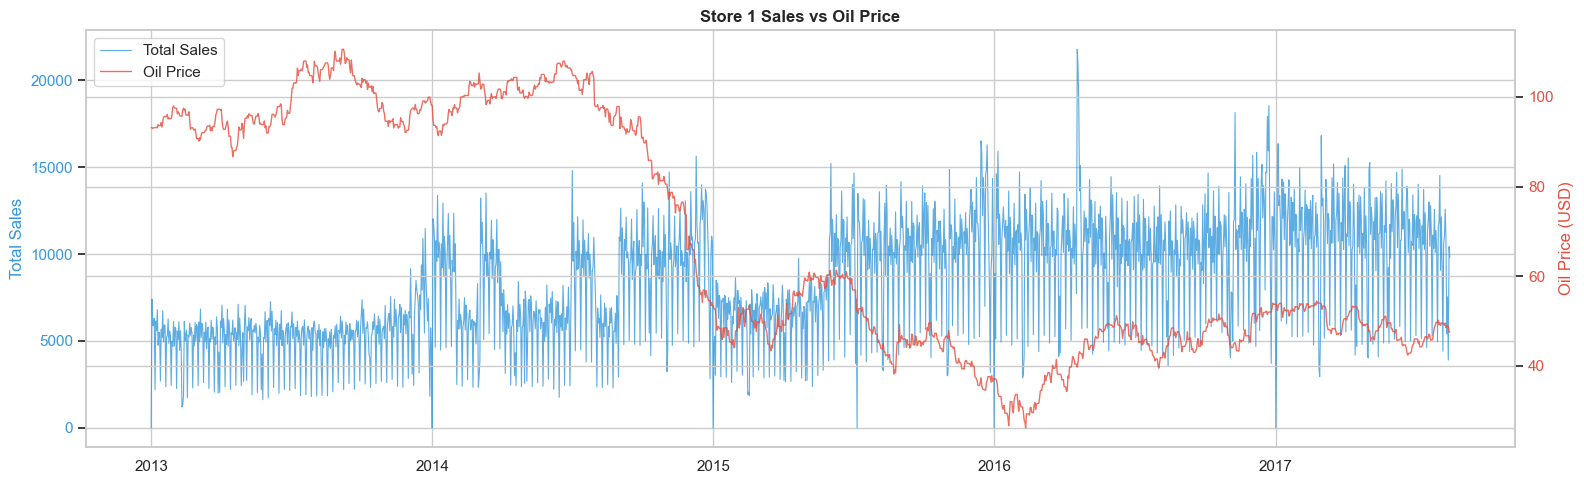

In [10]:
# Sales vs Oil Price

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(df.index, df['total_sales'],
         color='#3498db', linewidth=0.8,
         label='Total Sales', alpha=0.8)
ax1.set_ylabel('Total Sales', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(df.index, df['dcoilwtico'],
         color='#e74c3c', linewidth=1,
         label='Oil Price', alpha=0.8)
ax2.set_ylabel('Oil Price (USD)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Store 1 Sales vs Oil Price',
              fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/05_sales_vs_oil.png',
            dpi=150, bbox_inches='tight')
plt.show()